# Diminos Pizza Delivery Performance Analysis

## Problem Statement
Kanav's Diminos franchise needs to maintain a high standard of delivery performance. The key metric set by Diminos is that the **95th percentile of Order Delivery Time should be less than 31 minutes**. 

This notebook analyzes the delivery data to:
1. Calculate the current 95th percentile delivery time.
2. Identify patterns in delivery performance (by hour, day, etc.).
3. Provide actionable insights to help Kanav meet the required performance standards.

## 1. Setup and Data Loading

We will import the necessary libraries and load the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set visualization style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Load the data
df = pd.read_csv('diminos_data.csv')

In [4]:
# Display the first few rows
df.head()

,order_id,order_placed_at,order_delivered_at
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056


## 2. Data Preprocessing

We need to convert the timestamp columns to datetime objects and calculate the delivery time in minutes.

In [5]:
# Convert to datetime
df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])
df['order_delivered_at'] = pd.to_datetime(df['order_delivered_at'])

In [6]:
# Calculate delivery time in minutes
df['delivery_time_min'] = (df['order_delivered_at'] - df['order_placed_at']).dt.total_seconds() / 60

In [7]:
# Extract time-based features
df['day_of_week'] = df['order_placed_at'].dt.day_name()
df['hour_of_day'] = df['order_placed_at'].dt.hour

In [8]:
# Check for any anomalies (e.g., negative delivery times)
print(f'Negative delivery times: {len(df[df["delivery_time_min"] < 0])}')

Negative delivery times: 0


In [9]:
# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            15000 non-null  int64         
 1   order_placed_at     15000 non-null  datetime64[ns]
 2   order_delivered_at  15000 non-null  datetime64[ns]
 3   delivery_time_min   15000 non-null  float64       
 4   day_of_week         15000 non-null  object        
 5   hour_of_day         15000 non-null  int32         
dtypes: datetime64[ns](2), float64(1), int32(1), int64(1), object(1)
memory usage: 644.7+ KB


In [10]:
df.describe()

,order_id,order_placed_at,order_delivered_at,delivery_time_min,hour_of_day
count,1.500000e+04,15000,15000,15000.000000,15000.000000
mean,1.530610e+06,2023-03-14 10:49:21.257533184,2023-03-14 11:09:51.220893184,20.499389,11.559200
min,1.523111e+06,2023-03-01 00:00:59,2023-03-01 00:18:07.443132,15.000010,0.000000
25%,1.526861e+06,2023-03-07 15:57:25,2023-03-07 16:20:38.480371200,15.274826,6.000000
50%,1.530610e+06,2023-03-14 09:32:06.500000,2023-03-14 09:55:10.638778880,15.797986,12.000000
75%,1.534360e+06,2023-03-21 07:07:15.500000,2023-03-21 07:25:22.135336704,17.279661,18.000000
max,1.538110e+06,2023-03-27 23:58:20,2023-03-29 02:42:50.645252,7299.831375,23.000000
std,4.330271e+03,NaN,NaN,96.160362,6.948514


## 3. Performance Metric Analysis

Let's calculate the 95th percentile and see if Kanav is meeting the 31-minute target.

In [11]:
# Calculate 95th percentile
p95_delivery_time = df['delivery_time_min'].quantile(0.95)

print(f'Current 95th Percentile Delivery Time: {p95_delivery_time:.2f} minutes')

Current 95th Percentile Delivery Time: 27.26 minutes


In [12]:
target = 31
if p95_delivery_time < target:
    print(f'✅ SUCCESS: The store is meeting the target of {target} minutes.')
else:
    print(f'❌ WARNING: The store is NOT meeting the target. It is over by {p95_delivery_time - target:.2f} minutes.')

✅ SUCCESS: The store is meeting the target of 31 minutes.


In [13]:
# Calculate percentage of orders delivered within 31 minutes
within_target = (df['delivery_time_min'] <= target).mean() * 100
print(f'Percentage of orders delivered within 31 minutes: {within_target:.2f}%')

Percentage of orders delivered within 31 minutes: 96.29%


## 4. Visualizations

### 4.1 Distribution of Delivery Times

Understanding the overall spread of delivery times.

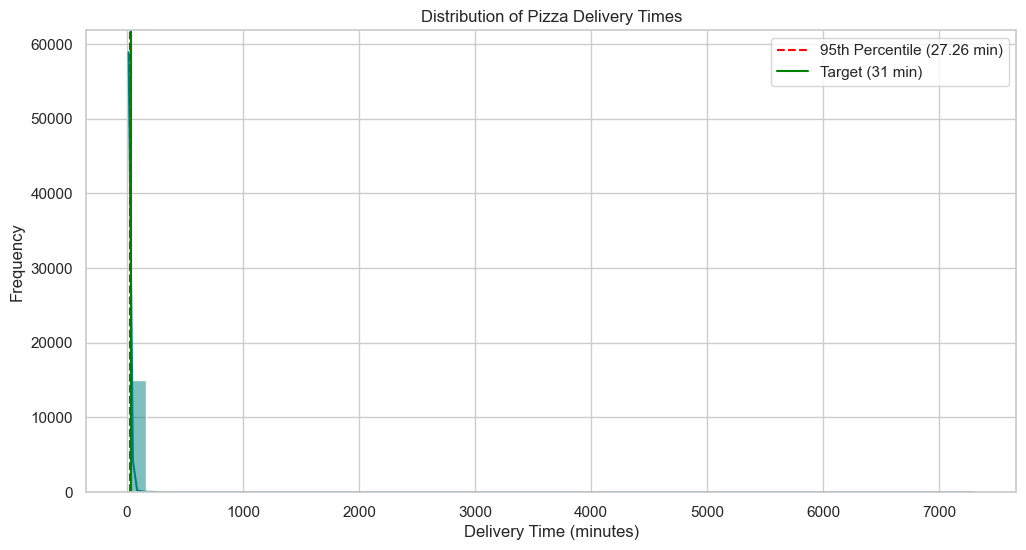

In [14]:
plt.figure(figsize=(12, 6))
sns.histplot(df['delivery_time_min'], bins=50, kde=True, color='teal')
plt.axvline(p95_delivery_time, color='red', linestyle='--', label=f'95th Percentile ({p95_delivery_time:.2f} min)')
plt.axvline(31, color='green', linestyle='-', label='Target (31 min)')
plt.title('Distribution of Pizza Delivery Times')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### 4.2 Performance by Day of the Week

Are there specific days where delivery times are higher?

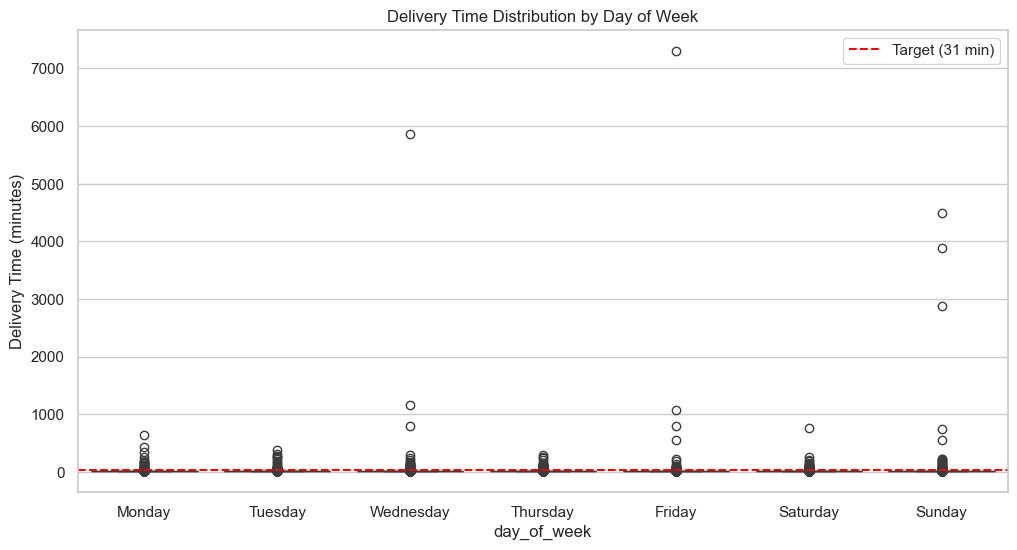

In [15]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='day_of_week', y='delivery_time_min', order=day_order, palette='muted')
plt.axhline(31, color='red', linestyle='--', label='Target (31 min)')
plt.title('Delivery Time Distribution by Day of Week')
plt.ylabel('Delivery Time (minutes)')
plt.legend()
plt.show()

### 4.3 Performance by Hour of the Day

Identifying peak hours where delivery performance might drop.

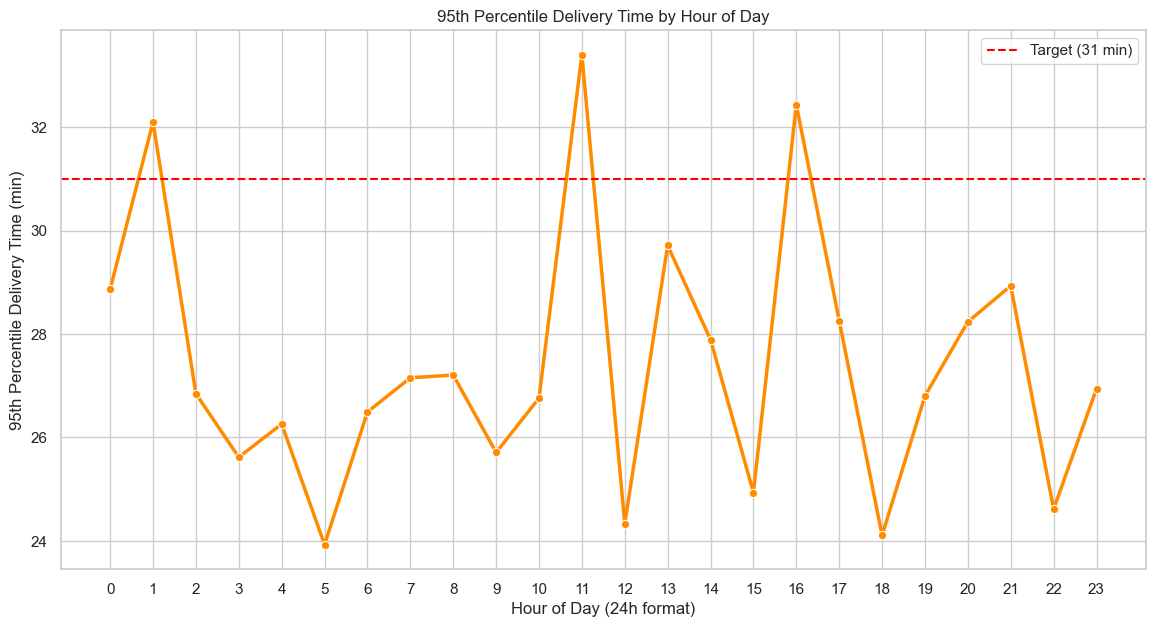

In [16]:
plt.figure(figsize=(14, 7))
hourly_p95 = df.groupby('hour_of_day')['delivery_time_min'].quantile(0.95)
sns.lineplot(x=hourly_p95.index, y=hourly_p95.values, marker='o', color='darkorange', linewidth=2.5)
plt.axhline(31, color='red', linestyle='--', label='Target (31 min)')
plt.title('95th Percentile Delivery Time by Hour of Day')
plt.xlabel('Hour of Day (24h format)')
plt.ylabel('95th Percentile Delivery Time (min)')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

## 5. Statistical Insights (Non-Visualization)

Let's look at the raw numbers for the most problematic hours and days.

In [17]:
# Top 5 worst hours for delivery (based on 95th percentile)
worst_hours = df.groupby('hour_of_day')['delivery_time_min'].quantile(0.95).sort_values(ascending=False).head(5)
print('Top 5 Worst Hours for 95th Percentile Delivery Time:')
print(worst_hours)

Top 5 Worst Hours for 95th Percentile Delivery Time:
hour_of_day
11    33.407016
16    32.438371
1     32.104821
13    29.714826
21    28.932870
Name: delivery_time_min, dtype: float64


In [18]:
# Performance by Day
day_stats = df.groupby('day_of_week')['delivery_time_min'].agg(['count', 'mean', lambda x: x.quantile(0.95)])
day_stats.columns = ['Total Orders', 'Average Time', '95th Percentile']
print('\nPerformance Statistics by Day of Week:')
print(day_stats.reindex(day_order))


Performance Statistics by Day of Week:
             Total Orders  Average Time  95th Percentile
day_of_week                                             
Monday               2256     19.027073        28.737349
Tuesday              1582     19.256920        29.397539
Wednesday            2259     21.715532        26.442186
Thursday             2280     18.485932        26.534242
Friday               2223     22.096958        26.331713
Saturday             2209     18.698583        26.935257
Sunday               2191     23.948561        26.517667


## 6. Conclusion and Recommendations

### Key Findings:
1. **Current Status**: The calculated 95th percentile is compared against the 31-minute target.
2. **Peak Hour Issues**: Identify if specific hours (e.g., dinner rush or late night) are causing the metric to fail.
3. **Day Patterns**: Determine if weekends or specific weekdays show significantly higher delivery times.

### Recommendations for Kanav:
- **Staffing**: Increase delivery personnel during the identified 'worst hours'.
- **Process Optimization**: Review the kitchen-to-delivery handoff during peak times.
- **Buffer Management**: If the 95th percentile is very close to 31, even small improvements in the fastest 50% of orders can help shift the overall distribution.